# Проверка продуктовых гипотез о WAV и доступности поездок

Период анализа - январь 2025 - апрель 2026. Анализ охватывает завершённые
поездки Uber и Lyft из NYC TLC FHVHV.

Проверяются три гипотезы:

1. В часы высокого спроса WAV чаще используется для обычных поездок.
2. Пассажиры инклюзивного сегмента ждут машину дольше.
3. Временной профиль спроса инклюзивного сегмента отличается от обычного.

## Контекст и методы

### Определения сегментов

- Инклюзивные поездки - `WAV request = Y` и/или `AAR = Y`.
- Обычные поездки на WAV - нет WAV request и AAR, но есть `WAV match = Y`.
- Обычные поездки - нет WAV request и AAR, независимо от типа автомобиля.

### Часы высокого спроса

- Будни: 08:00-08:59 и 17:00-21:59.
- Суббота и воскресенье: 17:00-23:59 и 00:00-00:59.

Эти интервалы ранее выбраны по общегородскому профилю всех поездок,
независимо от WAV-флагов. В текущем анализе определение зафиксировано и не
меняется между компаниями.

In [3]:
from pathlib import Path
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportions_ztest

warnings.filterwarnings('ignore', category=FutureWarning)

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent

MART_DIR = ROOT / 'data' / 'marts_product'
CELLS_PATH = MART_DIR / 'wav_dashboard_cells.parquet'
WAIT_HIST_PATH = MART_DIR / 'grafana_wait_hist_daily.parquet'
WAIT_SUMMARY_PATH = MART_DIR / 'wav_dashboard_wait_summary.parquet'

for required_path in (CELLS_PATH, WAIT_HIST_PATH, WAIT_SUMMARY_PATH):
    assert required_path.exists(), f'Не найдена витрина: {required_path}'

PEAK_HOURS = {
    'weekday': [8, 17, 18, 19, 20, 21],
    'weekend': [0, 17, 18, 19, 20, 21, 22, 23],
}
DAY_ORDER = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
DAY_LABELS = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 0: 'Вс'}
COLORS = {
    'Инклюзивные': '#73BF69',
    'Обычные': '#F2CC0C',
    'Часы высокого спроса': '#FF9830',
    'Остальные часы': '#73BF69',
}

RANDOM_SEED = 42
BOOTSTRAP_REPS = 2_000

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook', font_scale=0.95)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


def pvalue_text(pvalue: float) -> str:
    if pvalue < 1e-300:
        return '< 1e-300'
    if pvalue < 0.001:
        return f'{pvalue:.2e}'
    return f'{pvalue:.4f}'


def weighted_quantile(values: np.ndarray, counts: np.ndarray, quantile: float) -> float:
    cumulative = np.cumsum(counts)
    if cumulative[-1] <= 0:
        return np.nan
    index = np.searchsorted(cumulative, quantile * cumulative[-1], side='left')
    return float(values[min(index, len(values) - 1)])


def proportion_ci_difference(success_a, total_a, success_b, total_b, z_value=1.96):
    share_a = success_a / total_a
    share_b = success_b / total_b
    standard_error = np.sqrt(
        share_a * (1 - share_a) / total_a
        + share_b * (1 - share_b) / total_b
    )
    difference = share_a - share_b
    return difference, difference - z_value * standard_error, difference + z_value * standard_error

## Данные

Для гипотезы 1 используются агрегаты `зона × компания × тип часов` и
`дата × тип часов`. Для гипотезы 3 - дневные количества по часам. Время
ожидания хранится как дневная гистограмма с шагом 0,25 минуты; значения выше
180 минут объединены в верхнюю корзину. Медиана и p95 существенно ниже этого
ограничения.

In [4]:
cells_sql = CELLS_PATH.as_posix().replace("'", "''")
peak_sql = '''(
    (dow IN (0, 6) AND (hour = 0 OR hour BETWEEN 17 AND 23))
    OR (dow NOT IN (0, 6) AND (hour = 8 OR hour BETWEEN 17 AND 21))
)'''

con = duckdb.connect()
con.execute("SET memory_limit = '4GB'")
con.execute('SET threads = 4')

h1_counts = con.execute(f'''
    SELECT
        {peak_sql} AS high_demand,
        SUM(ordinary_trips)::BIGINT AS ordinary_trips,
        SUM(ordinary_wav_trips)::BIGINT AS ordinary_wav_trips
    FROM read_parquet('{cells_sql}')
    GROUP BY 1
    ORDER BY 1 DESC
''').fetchdf()

h1_daily = con.execute(f'''
    SELECT
        date,
        {peak_sql} AS high_demand,
        SUM(ordinary_trips)::BIGINT AS ordinary_trips,
        SUM(ordinary_wav_trips)::BIGINT AS ordinary_wav_trips
    FROM read_parquet('{cells_sql}')
    GROUP BY 1, 2
    ORDER BY 1, 2
''').fetchdf()

h1_zone = con.execute(f'''
    SELECT
        provider,
        PULocationID AS zone_id,
        {peak_sql} AS high_demand,
        SUM(ordinary_trips)::BIGINT AS ordinary_trips,
        SUM(ordinary_wav_trips)::BIGINT AS ordinary_wav_trips
    FROM read_parquet('{cells_sql}')
    GROUP BY 1, 2, 3
    HAVING SUM(ordinary_trips) > 0
    ORDER BY 1, 2, 3
''').fetchdf()

hourly_daily = con.execute(f'''
    SELECT
        date,
        provider,
        dow,
        hour,
        SUM(all_trips)::BIGINT AS all_trips,
        SUM(accessibility_trips)::BIGINT AS accessibility_trips,
        SUM(ordinary_trips)::BIGINT AS ordinary_trips
    FROM read_parquet('{cells_sql}')
    GROUP BY 1, 2, 3, 4
    ORDER BY 1, 2, 3, 4
''').fetchdf()
con.close()

wait_hist = pd.read_parquet(WAIT_HIST_PATH)
wait_summary = pd.read_parquet(WAIT_SUMMARY_PATH)

for frame in (h1_daily, hourly_daily, wait_hist):
    frame['date'] = pd.to_datetime(frame['date'])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
data_checks = pd.DataFrame({
    'Проверка': [
        'Период витрин',
        'Обычные WAV не превышают обычные поездки',
        'В гистограмме ожидания нет отрицательных значений',
        'Сегменты временного профиля складываются в общий объём',
    ],
    'Результат': [
        f"{hourly_daily['date'].min():%Y-%m-%d} - {hourly_daily['date'].max():%Y-%m-%d}",
        bool((h1_zone['ordinary_wav_trips'] <= h1_zone['ordinary_trips']).all()),
        bool((wait_hist['wait_bin_min'] >= 0).all()),
        bool((
            hourly_daily['accessibility_trips'] + hourly_daily['ordinary_trips']
            == hourly_daily['all_trips']
        ).all()),
    ],
})
display(data_checks)

assert (h1_zone['ordinary_wav_trips'] <= h1_zone['ordinary_trips']).all()
assert (wait_hist['wait_bin_min'] >= 0).all()
assert set(wait_hist['segment']) == {'Инклюзивные', 'Обычные'}
assert (
    hourly_daily['accessibility_trips'] + hourly_daily['ordinary_trips']
    == hourly_daily['all_trips']
).all()

,Проверка,Результат
0,Период витрин,2025-01-01 - 2026-04-30
1,Обычные WAV не превышают обычные поездки,True
2,В гистограмме ожидания нет отрицательных значений,True
3,Сегменты временного профиля складываются в общ...,True


## Гипотеза 1. Использование WAV в часы высокого спроса

**H₀:** доля обычных поездок на WAV среди обычных поездок одинакова в часы
высокого спроса и в остальные часы.

**H₁:** доля обычных поездок на WAV среди обычных поездок выше в часы
высокого спроса.

Основной - односторонний z-тест двух долей. Он трактует
поездки как независимые наблюдения, что для транспортных данных является
сильным допущением. Поэтому дополнительно рассчитывается бутстрэп по целым
датам и биномиальная регрессия с контролем компании и зоны.

,Период,Обычные поездки на WAV,Все обычные поездки,Доля WAV
0,Часы высокого спроса,"10,858,458","120,424,211",9.017%
1,Остальные часы,"17,389,954","205,798,399",8.450%


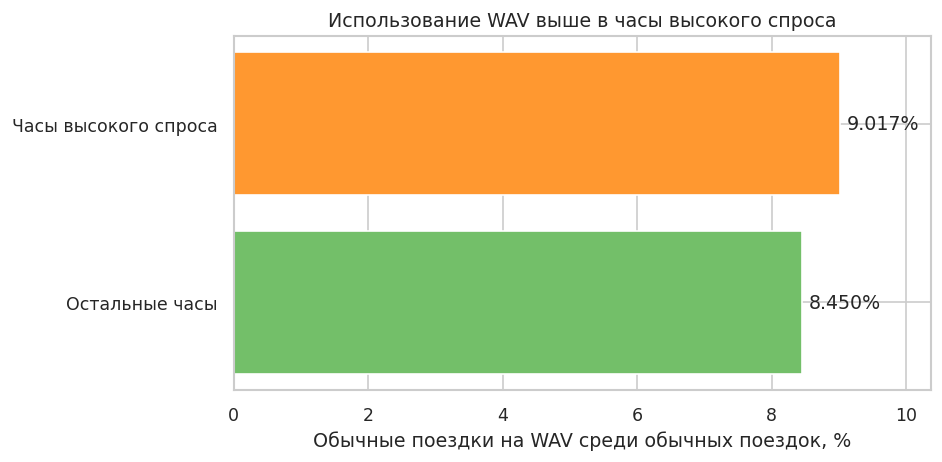

In [6]:
h1_counts = h1_counts.assign(
    period=np.where(h1_counts['high_demand'], 'Часы высокого спроса', 'Остальные часы'),
    wav_share=lambda data: data['ordinary_wav_trips'] / data['ordinary_trips'],
)

h1_display = h1_counts[
    ['period', 'ordinary_wav_trips', 'ordinary_trips', 'wav_share']
].rename(columns={
    'period': 'Период',
    'ordinary_wav_trips': 'Обычные поездки на WAV',
    'ordinary_trips': 'Все обычные поездки',
    'wav_share': 'Доля WAV',
})
display(h1_display.style.format({
    'Обычные поездки на WAV': '{:,.0f}',
    'Все обычные поездки': '{:,.0f}',
    'Доля WAV': '{:.3%}',
}))

fig, ax = plt.subplots(figsize=(8, 4))
plot_data = h1_counts.sort_values('high_demand')
bars = ax.barh(
    plot_data['period'],
    100 * plot_data['wav_share'],
    color=[COLORS[label] for label in plot_data['period']],
)
ax.bar_label(bars, fmt='%.3f%%', padding=4)
ax.set_xlabel('Обычные поездки на WAV среди обычных поездок, %')
ax.set_ylabel('')
ax.set_title('Использование WAV выше в часы высокого спроса')
ax.set_xlim(0, 1.15 * (100 * plot_data['wav_share']).max())
plt.tight_layout()
plt.show()

In [7]:
peak_row = h1_counts.loc[h1_counts['high_demand']].iloc[0]
other_row = h1_counts.loc[~h1_counts['high_demand']].iloc[0]

z_stat, z_pvalue = proportions_ztest(
    count=[peak_row['ordinary_wav_trips'], other_row['ordinary_wav_trips']],
    nobs=[peak_row['ordinary_trips'], other_row['ordinary_trips']],
    alternative='larger',
)
raw_difference, raw_ci_low, raw_ci_high = proportion_ci_difference(
    peak_row['ordinary_wav_trips'], peak_row['ordinary_trips'],
    other_row['ordinary_wav_trips'], other_row['ordinary_trips'],
)
relative_lift = peak_row['wav_share'] / other_row['wav_share'] - 1
cohens_h = 2 * (
    np.arcsin(np.sqrt(peak_row['wav_share']))
    - np.arcsin(np.sqrt(other_row['wav_share']))
)

# Бутстрэп переносит целые даты между итерациями и сохраняет внутридневную зависимость.
daily_wide = h1_daily.pivot(
    index='date', columns='high_demand',
    values=['ordinary_trips', 'ordinary_wav_trips'],
).dropna()
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_indices = rng.integers(
    0, len(daily_wide), size=(BOOTSTRAP_REPS, len(daily_wide)),
)
peak_success = daily_wide[('ordinary_wav_trips', True)].to_numpy()
peak_total = daily_wide[('ordinary_trips', True)].to_numpy()
other_success = daily_wide[('ordinary_wav_trips', False)].to_numpy()
other_total = daily_wide[('ordinary_trips', False)].to_numpy()
bootstrap_h1 = (
    peak_success[bootstrap_indices].sum(axis=1) / peak_total[bootstrap_indices].sum(axis=1)
    - other_success[bootstrap_indices].sum(axis=1) / other_total[bootstrap_indices].sum(axis=1)
)
h1_boot_ci = np.quantile(bootstrap_h1, [0.025, 0.975])

### Дополнительная биномиальная регрессия

В модели числитель - обычные поездки на WAV, знаменатель - все обычные
поездки. Контролируются компания и зона отправления. Робастные стандартные
ошибки кластеризуются по зонам, поскольку поездки одной зоны могут иметь
общие ненаблюдаемые особенности.

In [8]:
h1_model_data = h1_zone.copy()
h1_model_data['high_demand'] = h1_model_data['high_demand'].astype(float)
h1_model_data['is_lyft'] = (h1_model_data['provider'] == 'Lyft').astype(float)

zone_dummies = pd.get_dummies(
    h1_model_data['zone_id'].astype(str), prefix='zone', drop_first=True, dtype=float,
)
design_matrix = pd.concat(
    [
        pd.Series(1.0, index=h1_model_data.index, name='const'),
        h1_model_data[['high_demand', 'is_lyft']],
        zone_dummies,
    ],
    axis=1,
)
binomial_response = np.column_stack([
    h1_model_data['ordinary_wav_trips'],
    h1_model_data['ordinary_trips'] - h1_model_data['ordinary_wav_trips'],
])

h1_glm = sm.GLM(
    binomial_response,
    design_matrix,
    family=sm.families.Binomial(),
).fit(
    cov_type='cluster',
    cov_kwds={'groups': h1_model_data['zone_id']},
)

design_peak = design_matrix.copy()
design_peak['high_demand'] = 1.0
design_other = design_matrix.copy()
design_other['high_demand'] = 0.0
adjusted_delta = np.average(
    h1_glm.predict(design_peak) - h1_glm.predict(design_other),
    weights=h1_model_data['ordinary_trips'],
)
peak_odds_ratio = np.exp(h1_glm.params['high_demand'])
peak_or_ci = np.exp(h1_glm.conf_int().loc['high_demand'].to_numpy())
peak_model_pvalue = h1_glm.pvalues['high_demand']

h1_results = pd.DataFrame({
    'Показатель': [
        'Доля в часы высокого спроса',
        'Доля в остальные часы',
        'Наблюдаемая разница',
        'Относительный рост',
        '95% CI разницы - бутстрэп по датам',
        'Cohen h',
        'Odds ratio - модель с контролями',
        'Скорректированная разница - модель',
    ],
    'Результат': [
        f"{peak_row['wav_share']:.3%}",
        f"{other_row['wav_share']:.3%}",
        f'{100 * raw_difference:+.3f} п.п.',
        f'{relative_lift:+.2%}',
        f'[{100 * h1_boot_ci[0]:+.3f}; {100 * h1_boot_ci[1]:+.3f}] п.п.',
        f'{cohens_h:.4f}',
        f'{peak_odds_ratio:.4f} [{peak_or_ci[0]:.4f}; {peak_or_ci[1]:.4f}]',
        f'{100 * adjusted_delta:+.3f} п.п.',
    ],
})
display(h1_results)

display(Markdown(
    f'''**Статистический вывод.** Односторонний z-тест даёт `z = {z_stat:,.2f}` и
`p {pvalue_text(z_pvalue)}`. Однако из-за зависимости поездок этот p-value
слишком оптимистичен. Более надёжный бутстрэп по датам оценивает разницу в
**{100 * raw_difference:+.3f} п.п.** с 95%-м интервалом
**[{100 * h1_boot_ci[0]:+.3f}; {100 * h1_boot_ci[1]:+.3f}] п.п.**.'''
))

,Показатель,Результат
0,Доля в часы высокого спроса,9.017%
1,Доля в остальные часы,8.450%
2,Наблюдаемая разница,+0.567 п.п.
3,Относительный рост,+6.71%
4,95% CI разницы - бутстрэп по датам,[+0.532; +0.599] п.п.
5,Cohen h,0.0201
6,Odds ratio - модель с контролями,1.0769 [1.0555; 1.0987]
7,Скорректированная разница - модель,+0.587 п.п.


**Статистический вывод.** Односторонний z-тест даёт `z = 175.68` и
`p < 1e-300`. Однако из-за зависимости поездок этот p-value
слишком оптимистичен. Более надёжный бутстрэп по датам оценивает разницу в
**+0.567 п.п.** с 95%-м интервалом
**[+0.532; +0.599] п.п.**.

Выводы: в часы высокого спроса обычные поездки действительно немного чаще выполняются на WAV. Связь сохраняется после контроля компании и зоны: скорректированная разница составляет +0.587 п.п., p 4.63e-13. При этом Cohen's h = 0.0201, то есть эффект мал по величине. Результат согласуется с гипотезой о подключении WAV к общему спросу, но не доказывает нехватку обычного транспорта: в данных нет свободного флота, алгоритма назначения и отменённых заказов.

## Гипотеза 2. Различие времени ожидания

**H₀:** распределения времени ожидания инклюзивных и обычных поездок не
различаются.

**H₁:** время ожидания инклюзивных поездок больше.

Для поездок на WAV с валидным `on_scene_datetime` ожидание считается от
запроса до прибытия автомобиля. В остальных случаях используется интервал до
`pickup_datetime`. Отрицательные и нарушающие хронологию интервалы исключены.

Тест Манна-Уитни проводится по взвешенной гистограмме. Он проверяет ранговый сдвиг распределений, а не строго
равенство медиан. Доверительные интервалы медианы и p95 строятся бутстрэпом по
целым датам.

In [9]:
wait_overall = (
    wait_hist.groupby(['segment', 'wait_bin_min'], as_index=False)['trips']
    .sum()
    .sort_values(['segment', 'wait_bin_min'])
)
wait_bins = np.sort(wait_overall['wait_bin_min'].unique())

segment_counts = {}
for segment in ('Инклюзивные', 'Обычные'):
    segment_counts[segment] = (
        wait_overall.loc[wait_overall['segment'] == segment]
        .set_index('wait_bin_min')['trips']
        .reindex(wait_bins, fill_value=0)
        .to_numpy(dtype=float)
    )

inclusive_counts = segment_counts['Инклюзивные']
ordinary_counts = segment_counts['Обычные']
inclusive_n = inclusive_counts.sum()
ordinary_n = ordinary_counts.sum()

wait_metrics = {}
for segment, counts in segment_counts.items():
    wait_metrics[segment] = {
        'n': counts.sum(),
        'median': weighted_quantile(wait_bins, counts, 0.50),
        'p95': weighted_quantile(wait_bins, counts, 0.95),
        'p99': weighted_quantile(wait_bins, counts, 0.99),
    }

# U = число пар, где ожидание инклюзивной поездки больше обычной,
# плюс половина пар с одинаковым округлённым ожиданием.
ordinary_less = np.cumsum(ordinary_counts) - ordinary_counts
mann_u = np.sum(inclusive_counts * (ordinary_less + 0.5 * ordinary_counts))
combined_ties = inclusive_counts + ordinary_counts
total_n = inclusive_n + ordinary_n
tie_term = np.sum(combined_ties**3 - combined_ties)
mann_variance = inclusive_n * ordinary_n / 12 * (
    total_n + 1 - tie_term / (total_n * (total_n - 1))
)
mann_z = (mann_u - inclusive_n * ordinary_n / 2 - 0.5) / np.sqrt(mann_variance)
mann_pvalue = norm.sf(mann_z)
probability_superiority = mann_u / (inclusive_n * ordinary_n)
rank_biserial = 2 * probability_superiority - 1

In [10]:
coverage = wait_summary.loc[
    wait_summary['provider'] == 'Все',
    ['segment', 'trips', 'valid_wait_n', 'excluded_negative_n',
     'excluded_on_scene_after_pickup_n'],
].copy()
coverage['valid_share'] = coverage['valid_wait_n'] / coverage['trips']
coverage_by_segment = coverage.set_index('segment')
inclusive_valid_share = coverage_by_segment.loc['Инклюзивные', 'valid_share']
ordinary_valid_share = coverage_by_segment.loc['Обычные', 'valid_share']
display(coverage.style.format({
    'trips': '{:,.0f}',
    'valid_wait_n': '{:,.0f}',
    'excluded_negative_n': '{:,.0f}',
    'excluded_on_scene_after_pickup_n': '{:,.0f}',
    'valid_share': '{:.2%}',
}))

wait_metric_table = pd.DataFrame(wait_metrics).T.reset_index(names='Сегмент')
wait_metric_table = wait_metric_table.rename(columns={
    'n': 'Валидных ожиданий', 'median': 'Медиана, мин',
    'p95': 'P95, мин', 'p99': 'P99, мин',
})
display(wait_metric_table.style.format({
    'Валидных ожиданий': '{:,.0f}',
    'Медиана, мин': '{:.2f}',
    'P95, мин': '{:.2f}',
    'P99, мин': '{:.2f}',
}))

,segment,trips,valid_wait_n,excluded_negative_n,excluded_on_scene_after_pickup_n,valid_share
4,Инклюзивные,"1,223,697","1,038,712","184,984",7,84.88%
5,Обычные,"326,222,610","321,218,807","5,001,874","56,559",98.47%


,Сегмент,Валидных ожиданий,"Медиана, мин","P95, мин","P99, мин"
0,Инклюзивные,"1,038,754",4.75,12.25,18.50
1,Обычные,"322,389,442",4.00,11.25,17.00


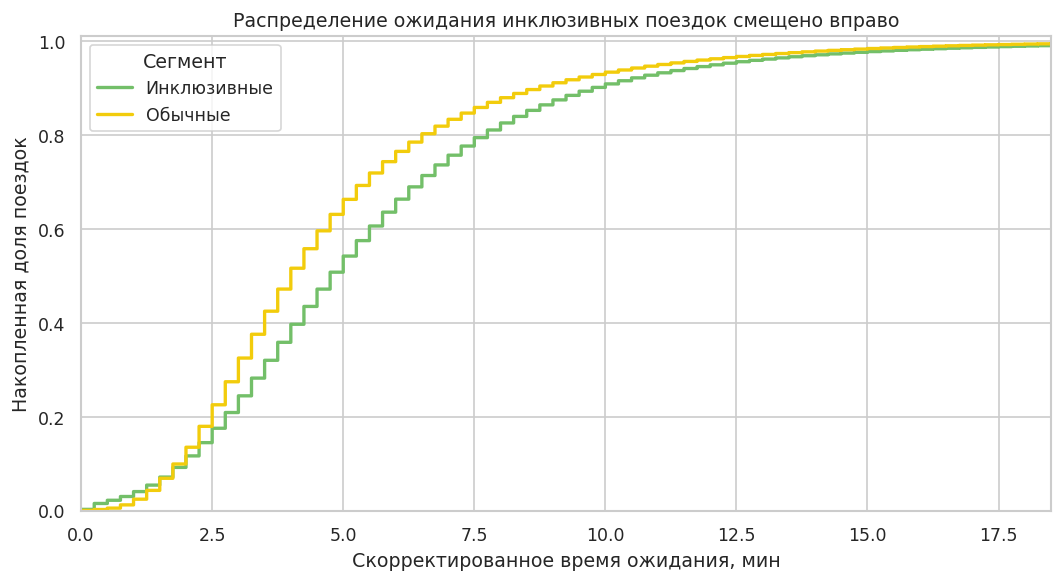

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
for segment, counts in segment_counts.items():
    cumulative_share = np.cumsum(counts) / counts.sum()
    ax.step(
        wait_bins, cumulative_share,
        where='post', label=segment, color=COLORS[segment], linewidth=2,
    )
ax.set_xlim(0, max(wait_metrics[segment]['p99'] for segment in wait_metrics))
ax.set_ylim(0, 1.01)
ax.set_xlabel('Скорректированное время ожидания, мин')
ax.set_ylabel('Накопленная доля поездок')
ax.set_title('Распределение ожидания инклюзивных поездок смещено вправо')
ax.legend(title='Сегмент')
plt.tight_layout()
plt.show()

### Бутстрэп медианы и p95 по датам

В каждой итерации с возвращением выбирается столько же целых дат, сколько
наблюдалось в данных. Одна и та же выборка дат применяется к обоим сегментам,
поэтому сохраняются общие календарные шоки. Интервал отражает вариативность
между датами, но не учитывает дополнительную кластеризацию внутри зон.

In [12]:
bootstrap_dates = np.sort(wait_hist['date'].unique())
bootstrap_bins = np.sort(wait_hist['wait_bin_min'].unique())
daily_matrices = {}
for segment in ('Инклюзивные', 'Обычные'):
    daily_matrices[segment] = (
        wait_hist.loc[wait_hist['segment'] == segment]
        .pivot_table(
            index='date', columns='wait_bin_min', values='trips',
            aggfunc='sum', fill_value=0,
        )
        .reindex(index=bootstrap_dates, columns=bootstrap_bins, fill_value=0)
        .to_numpy(dtype=float)
    )


def quantiles_from_count_matrix(count_matrix, bins, quantile):
    cumulative = np.cumsum(count_matrix, axis=1)
    thresholds = quantile * cumulative[:, -1]
    indices = (cumulative >= thresholds[:, None]).argmax(axis=1)
    return bins[indices]


rng = np.random.default_rng(RANDOM_SEED)
median_differences = []
p95_differences = []
batch_size = 100
for batch_start in range(0, BOOTSTRAP_REPS, batch_size):
    current_batch = min(batch_size, BOOTSTRAP_REPS - batch_start)
    date_weights = rng.multinomial(
        len(bootstrap_dates),
        np.full(len(bootstrap_dates), 1 / len(bootstrap_dates)),
        size=current_batch,
    )
    inclusive_boot = date_weights @ daily_matrices['Инклюзивные']
    ordinary_boot = date_weights @ daily_matrices['Обычные']
    median_differences.extend(
        quantiles_from_count_matrix(inclusive_boot, bootstrap_bins, 0.50)
        - quantiles_from_count_matrix(ordinary_boot, bootstrap_bins, 0.50)
    )
    p95_differences.extend(
        quantiles_from_count_matrix(inclusive_boot, bootstrap_bins, 0.95)
        - quantiles_from_count_matrix(ordinary_boot, bootstrap_bins, 0.95)
    )

median_differences = np.asarray(median_differences)
p95_differences = np.asarray(p95_differences)
median_ci = np.quantile(median_differences, [0.025, 0.975])
p95_ci = np.quantile(p95_differences, [0.025, 0.975])

median_difference = (
    wait_metrics['Инклюзивные']['median'] - wait_metrics['Обычные']['median']
)
p95_difference = wait_metrics['Инклюзивные']['p95'] - wait_metrics['Обычные']['p95']

bootstrap_table = pd.DataFrame({
    'Метрика': ['Разница медиан', 'Разница p95'],
    'Оценка, мин': [median_difference, p95_difference],
    'Нижняя граница 95% CI': [median_ci[0], p95_ci[0]],
    'Верхняя граница 95% CI': [median_ci[1], p95_ci[1]],
})
display(bootstrap_table.style.format({
    'Оценка, мин': '{:+.2f}',
    'Нижняя граница 95% CI': '{:+.2f}',
    'Верхняя граница 95% CI': '{:+.2f}',
}))

display(Markdown(
    f'''**Статистический вывод.** Взвешенный тест Манна-Уитни даёт
`z = {mann_z:,.2f}`, `p {pvalue_text(mann_pvalue)}`. Вероятность того, что
случайная инклюзивная поездка имеет большее ожидание, чем случайная обычная
поездка, с учётом половины совпадений, равна **{probability_superiority:.2%}**;
ранговая корреляция составляет **{rank_biserial:.4f}**.'''
))

,Метрика,"Оценка, мин",Нижняя граница 95% CI,Верхняя граница 95% CI
0,Разница медиан,+0.75,+0.75,+0.75
1,Разница p95,+1.00,+0.75,+1.25


**Статистический вывод.** Взвешенный тест Манна-Уитни даёт
`z = 248.47`, `p < 1e-300`. Вероятность того, что
случайная инклюзивная поездка имеет большее ожидание, чем случайная обычная
поездка, с учётом половины совпадений, равна **57.04%**;
ранговая корреляция составляет **0.1409**.

Медиана инклюзивного сегмента выше на +0.75 мин с 95%-м бутстрэп-интервалом [+0.75; +0.75], а p95 - на +1.00 мин с интервалом [+0.75; +1.25]. Разрыв присутствует не только в центре, но и в правом хвосте распределения. Однако валидное ожидание доступно для 84.9% инклюзивных и 98.5% обычных поездок. Поэтому вывод относится к поездкам с корректной хронологией, а неодинаковая доля исключений может смещать оценку. Кроме того, для части WAV ожидание измеряется до on_scene, а для остальных поездок - до pickup: это исключает время посадки там, где on_scene доступен, но не создаёт полностью идентичную точку измерения для сегментов.

## Гипотеза 3. Различие временных паттернов спроса

**H₀:** распределение поездок между 168 слотами `день недели × час` одинаково
для инклюзивных и обычных поездок.

**H₁:** распределения поездок по сегментам различаются.

Основной тест - χ²-тест независимости. Из-за большого объёма рядом приводятся
Cramér's V и Jensen-Shannon distance. Они показывают величину различия, а
стандартизованные остатки помогают найти конкретные временные слоты.

In [13]:
temporal_counts = (
    hourly_daily.groupby(['dow', 'hour'], as_index=False)[
        ['accessibility_trips', 'ordinary_trips']
    ].sum()
)
temporal_counts['day'] = temporal_counts['dow'].map(DAY_LABELS)
temporal_counts['slot'] = temporal_counts['day'] + ' ' + temporal_counts['hour'].map(
    lambda hour: f'{hour:02d}:00'
)

contingency = np.vstack([
    temporal_counts['accessibility_trips'].to_numpy(),
    temporal_counts['ordinary_trips'].to_numpy(),
])
chi2_stat, chi2_pvalue, chi2_dof, expected = chi2_contingency(contingency)
cramers_v = np.sqrt(chi2_stat / (contingency.sum() * min(contingency.shape[0] - 1, contingency.shape[1] - 1)))

inclusive_profile = contingency[0] / contingency[0].sum()
ordinary_profile = contingency[1] / contingency[1].sum()
js_distance = jensenshannon(inclusive_profile, ordinary_profile, base=2)
standardized_residuals = (contingency - expected) / np.sqrt(expected)

temporal_counts['inclusive_share_pct'] = 100 * inclusive_profile
temporal_counts['ordinary_share_pct'] = 100 * ordinary_profile
temporal_counts['difference_pp'] = 100 * (inclusive_profile - ordinary_profile)
temporal_counts['inclusive_standardized_residual'] = standardized_residuals[0]

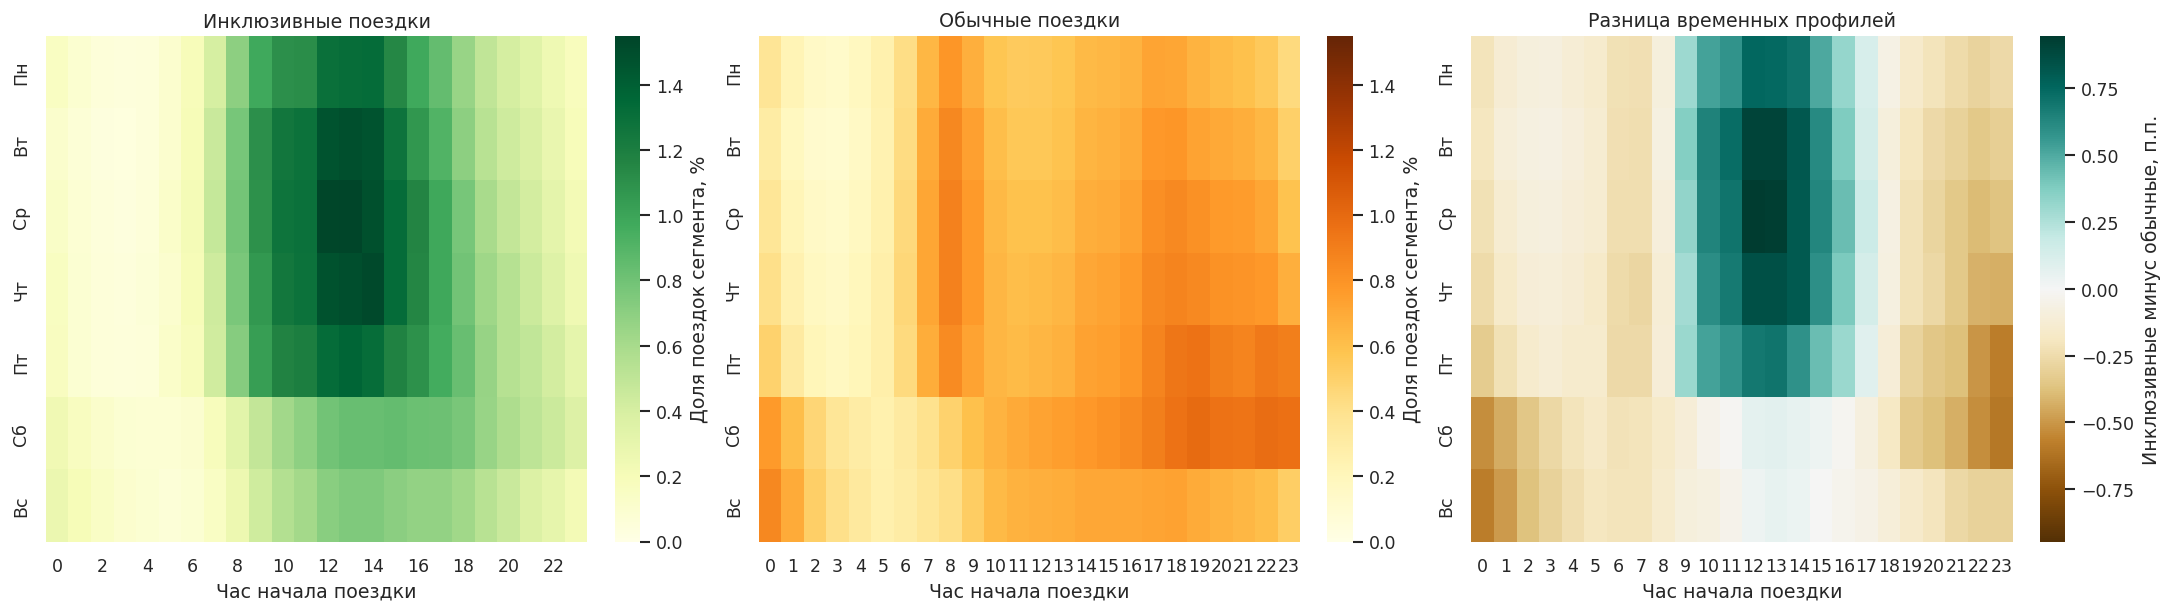

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
heatmap_specs = [
    ('inclusive_share_pct', 'Инклюзивные поездки', 'YlGn'),
    ('ordinary_share_pct', 'Обычные поездки', 'YlOrBr'),
]
shared_max = max(
    temporal_counts['inclusive_share_pct'].max(),
    temporal_counts['ordinary_share_pct'].max(),
)

for axis, (column, title, color_map) in zip(axes[:2], heatmap_specs):
    matrix = (
        temporal_counts.pivot(index='day', columns='hour', values=column)
        .reindex(DAY_ORDER)
        .reindex(columns=range(24))
    )
    sns.heatmap(
        matrix, ax=axis, cmap=color_map, vmin=0, vmax=shared_max,
        cbar_kws={'label': 'Доля поездок сегмента, %'},
    )
    axis.set_title(title)
    axis.set_xlabel('Час начала поездки')
    axis.set_ylabel('')

difference_matrix = (
    temporal_counts.pivot(index='day', columns='hour', values='difference_pp')
    .reindex(DAY_ORDER)
    .reindex(columns=range(24))
)
difference_limit = np.abs(difference_matrix.to_numpy()).max()
sns.heatmap(
    difference_matrix, ax=axes[2], cmap='BrBG', center=0,
    vmin=-difference_limit, vmax=difference_limit,
    cbar_kws={'label': 'Инклюзивные минус обычные, п.п.'},
)
axes[2].set_title('Разница временных профилей')
axes[2].set_xlabel('Час начала поездки')
axes[2].set_ylabel('')
plt.show()

In [15]:
top_inclusive_slots = temporal_counts.nlargest(6, 'difference_pp')[
    ['slot', 'inclusive_share_pct', 'ordinary_share_pct', 'difference_pp',
     'inclusive_standardized_residual']
].copy()
top_ordinary_slots = temporal_counts.nsmallest(6, 'difference_pp')[
    ['slot', 'inclusive_share_pct', 'ordinary_share_pct', 'difference_pp',
     'inclusive_standardized_residual']
].copy()

slot_comparison = pd.concat([
    top_inclusive_slots.assign(interpretation='Относительно чаще у инклюзивного сегмента'),
    top_ordinary_slots.assign(interpretation='Относительно чаще у обычного сегмента'),
], ignore_index=True)
display(slot_comparison.rename(columns={
    'slot': 'Слот',
    'inclusive_share_pct': 'Инклюзивные, % профиля',
    'ordinary_share_pct': 'Обычные, % профиля',
    'difference_pp': 'Разница, п.п.',
    'inclusive_standardized_residual': 'Стандартизованный остаток',
    'interpretation': 'Интерпретация',
}).style.format({
    'Инклюзивные, % профиля': '{:.3f}',
    'Обычные, % профиля': '{:.3f}',
    'Разница, п.п.': '{:+.3f}',
    'Стандартизованный остаток': '{:+.1f}',
}))

,Слот,"Инклюзивные, % профиля","Обычные, % профиля","Разница, п.п.",Стандартизованный остаток,Интерпретация
0,Ср 12:00,1.537,0.591,+0.947,+135.3,Относительно чаще у инклюзивного сегмента
1,Ср 13:00,1.549,0.616,+0.933,+130.7,Относительно чаще у инклюзивного сегмента
2,Вт 12:00,1.465,0.559,+0.906,+133.2,Относительно чаще у инклюзивного сегмента
3,Вт 13:00,1.490,0.584,+0.906,+130.3,Относительно чаще у инклюзивного сегмента
4,Чт 13:00,1.500,0.642,+0.857,+117.6,Относительно чаще у инклюзивного сегмента
5,Чт 12:00,1.471,0.618,+0.853,+119.3,Относительно чаще у инклюзивного сегмента
6,Сб 23:00,0.365,0.966,-0.601,-67.5,Относительно чаще у обычного сегмента
7,Пт 23:00,0.313,0.897,-0.584,-68.0,Относительно чаще у обычного сегмента
8,Вс 00:00,0.276,0.854,-0.579,-69.1,Относительно чаще у обычного сегмента
9,Сб 22:00,0.452,0.984,-0.531,-59.1,Относительно чаще у обычного сегмента


### Дополнительная линейная модель

Сырые количества сильно скошены, поэтому модель строится для `log(1 + число
поездок)`. Взаимодействие сегмента со 168 временными слотами проверяет, меняется
ли разрыв между сегментами в разные часы недели. Компания и месяц включены как
контрольные признаки, стандартные ошибки кластеризуются по датам. Признак
часа высокого спроса отдельно не добавляется, поскольку он полностью
определяется временным слотом.

In [16]:
hourly_long = pd.concat([
    hourly_daily[['date', 'provider', 'dow', 'hour', 'accessibility_trips']]
    .rename(columns={'accessibility_trips': 'trips'})
    .assign(is_accessibility=1.0),
    hourly_daily[['date', 'provider', 'dow', 'hour', 'ordinary_trips']]
    .rename(columns={'ordinary_trips': 'trips'})
    .assign(is_accessibility=0.0),
], ignore_index=True)
hourly_long['slot'] = hourly_long['dow'] * 24 + hourly_long['hour']
hourly_long['month'] = hourly_long['date'].dt.to_period('M').astype(str)
hourly_long['log1p_trips'] = np.log1p(hourly_long['trips'])

h3_ols = smf.ols(
    'log1p_trips ~ is_accessibility * C(slot) + C(provider) + C(month)',
    data=hourly_long,
).fit(
    cov_type='cluster',
    cov_kwds={'groups': hourly_long['date']},
)

interaction_names = [
    name for name in h3_ols.params.index
    if name.startswith('is_accessibility:C(slot)')
]
restriction_matrix = np.zeros((len(interaction_names), len(h3_ols.params)))
parameter_positions = {name: index for index, name in enumerate(h3_ols.params.index)}
for row_index, parameter_name in enumerate(interaction_names):
    restriction_matrix[row_index, parameter_positions[parameter_name]] = 1

interaction_test = h3_ols.wald_test(restriction_matrix, scalar=True)
interaction_pvalue = float(interaction_test.pvalue)

max_positive = temporal_counts.loc[temporal_counts['difference_pp'].idxmax()]
max_negative = temporal_counts.loc[temporal_counts['difference_pp'].idxmin()]

chi_results = pd.DataFrame({
    'Показатель': [
        'χ²', 'Степени свободы', 'p-value χ²', "Cramér's V",
        'Jensen-Shannon distance', 'p-value взаимодействий регрессии',
    ],
    'Результат': [
        f'{chi2_stat:,.1f}', f'{chi2_dof}', pvalue_text(chi2_pvalue),
        f'{cramers_v:.4f}', f'{js_distance:.4f}', pvalue_text(interaction_pvalue),
    ],
})
display(chi_results)

display(Markdown(
    f'''**Статистический вывод.** χ²-тест отвергает независимость сегмента и
временного слота: `χ²({chi2_dof}) = {chi2_stat:,.1f}`, `p {pvalue_text(chi2_pvalue)}`.
При этом Cramér's V = **{cramers_v:.4f}**, Jensen-Shannon distance =
**{js_distance:.4f}**. Это означает, что различие систематическое, но его
практический масштаб нужно оценивать по конкретным слотам, а не по p-value.

**Бизнес-смысл.** Максимальное положительное отклонение инклюзивного профиля
наблюдается в слоте **{max_positive['slot']}**:
**{max_positive['inclusive_share_pct']:.3f}%** недельного спроса сегмента против
**{max_positive['ordinary_share_pct']:.3f}%** у обычных поездок, разница
**{max_positive['difference_pp']:+.3f} п.п.** Максимальное смещение в сторону
обычного сегмента приходится на **{max_negative['slot']}** с разницей
**{max_negative['difference_pp']:+.3f} п.п.** Совместный тест взаимодействий в
регрессии с контролем компании и месяца также даёт
`p {pvalue_text(interaction_pvalue)}`. Следовательно, единый профиль предложения
по часам может хуже соответствовать инклюзивному спросу; операционное решение
следует принимать по слотам с заметной разницей долей, а не по одному общему
результату χ².'''
))

,Показатель,Результат
0,χ²,"481,702.2"
1,Степени свободы,167
2,p-value χ²,< 1e-300
3,Cramér's V,0.0384
4,Jensen-Shannon distance,0.2570
5,p-value взаимодействий регрессии,< 1e-300


**Статистический вывод.** χ²-тест отвергает независимость сегмента и
временного слота: `χ²(167) = 481,702.2`, `p < 1e-300`.
При этом Cramér's V = **0.0384**, Jensen-Shannon distance =
**0.2570**. Это означает, что различие систематическое, но его
практический масштаб нужно оценивать по конкретным слотам, а не по p-value.

**Бизнес-смысл.** Максимальное положительное отклонение инклюзивного профиля
наблюдается в слоте **Ср 12:00**:
**1.537%** недельного спроса сегмента против
**0.591%** у обычных поездок, разница
**+0.947 п.п.** Максимальное смещение в сторону
обычного сегмента приходится на **Сб 23:00** с разницей
**-0.601 п.п.** Совместный тест взаимодействий в
регрессии с контролем компании и месяца также даёт
`p < 1e-300`. Следовательно, единый профиль предложения
по часам может хуже соответствовать инклюзивному спросу; операционное решение
следует принимать по слотам с заметной разницей долей, а не по одному общему
результату χ².

## tl;dr

1. Гипотеза 1 - поддерживается. В часы высокого спроса доля обычных поездок на WAV выше на +0.567 п.п.; бутстрэп по датам даёт 95%-й интервал [+0.532; +0.599] п.п.. Эффект устойчив, но мал и не доказывает дефицит обычного флота.
2. Гипотеза 2 - поддерживается. Среди поездок с валидным временем инклюзивные поездки имеют медиану ожидания выше на +0.75 мин, а p95 - на +1.00 мин. Интервалы бутстрэпа по датам: [+0.75; +0.75] и [+0.75; +1.25] мин соответственно.
3. Гипотеза 3 - поддерживается. Временные профили статистически различаются (p < 1e-300), но размер общего эффекта невелик: Cramér's V = 0.0384. Наибольшее положительное отклонение инклюзивного спроса приходится на Ср 12:00, разница +0.947 п.п..

## Итоговые выводы

1. Повышенный спрос связан с более частым использованием WAV для обычных
   поездок, но эффект небольшой. Чтобы проверить механизм нехватки обычных
   машин, нужны данные о доступном флоте, назначениях и отменах.
2. Разрыв ожидания инклюзивного сегмента присутствует и в центре, и в хвосте
   распределения, но покрытие метрики неодинаково: около 84,9% против 98,5%.
   Следующий шаг - проверить чувствительность на единой метрике
   `request → pickup`, а затем повторить оценку внутри одинаковых
   `компания × зона × день недели × час × месяц`, чтобы отделить качество
   сервиса от различий в составе поездок и механизма пропусков.
3. Временные паттерны различаются статистически, однако общий размер эффекта
   мал. Планирование флота стоит ориентировать на конкретные слоты с устойчивой
   разницей, проверенной отдельно по Uber и Lyft.